## 1. Introduction
- **Quantum teleportation:** Using a shared entangled state (sometimes called an **e-bit**) to send an unknown quantum state to a distant friend, requiring supplemental calssical communication.
- **Quantum superdense coding:** How to send two bits of information by sending a single qubit to a distant friend (again using prior shared entangled qubits).

the so called "**unknown quantum state**" simply refers to a state of the form described as:
$$|\psi\rangle = \alpha |0\rangle + \beta|1\rangle$$

where $\alpha$ and $\beta$ are complex numbers such that $|\alpha|^2 + |\beta|^2 = 1$.

This allows us to write the quantum state as
$$ |\psi\rangle = cos{\frac{\theta}{2}}|0\rangle + e^{i\varphi} sin{\frac{\theta}{2}} |1\rangle = \begin{pmatrix} cos\frac{\theta}{2} \\ e^{i\varphi} sin\frac{\theta}{2} \end{pmatrix}$$

## 2. Density matrices
We can also write the quantum state $|\psi\rangle$ as its density matrix. This form is useful for denoting probabilistic mixture of pure quantum states. In the case of a single qubit, we can write:

$$|\psi\rangle\langle\psi| \equiv \rho = \begin{pmatrix}cos\frac{\theta}{2} \\ e^{i\varphi}sin\frac{\theta}{2}\end{pmatrix}\begin{pmatrix} cos\frac{\theta}{2} & e^{-i\varphi}sin\frac{\theta}{2} \end{pmatrix} = \frac{1}{2}\begin{pmatrix} 1+cos\theta & e^{-i\varphi}sin\theta \\ e^{-i\varphi}sin\theta & 1-cos\theta \end{pmatrix}$$

Note that the density matrix $\rho$ can be represented with a linear summation of Pauli matrices:
$$\rho = \frac{1}{2}\left(I+(sin\theta cos\varphi)X+(sin\theta sin\varphi)Y+(cos\theta)Z\right)$$
Or, in general,
$$ \rho=\frac{1}{2}(I+r_x X+r_y Y+r_z Z)$$
where $r_x^2+r_y^2+r_z^2 = 1$.\
And, the Bloch vector is **r**=$(r_x,r_y,r_z)$.

In [1]:
import numpy as np

# create a random 1-qubit state from a random (theta, varphi) to define r vector
np.random.seed(1)  # fixing seed for repeatibility

theta = np.random.uniform(0.0, 1.0) * np.pi  # from 0 to pi
varphi = np.random.uniform(0.0, 2.0) * np.pi  # from 0 to 2*pi


def get_r_vec(theta, varphi):
    rx = np.sin(theta) * np.cos(varphi)
    ry = np.sin(theta) * np.sin(varphi)
    rz = np.cos(theta)
    return (rx, ry, rz)


# get r vector
rx, ry, rz = get_r_vec(theta, varphi)

print("theta=" + str(theta), ",varphi=" + str(varphi))
print("(rx, ry, rz) = (" + str(rx) + ", " + str(ry) + ", " + str(rz) + ")")

theta=1.3101132663588946 ,varphi=4.525932273597346
(rx, ry, rz) = (-0.1791150283307452, -0.9494670044331133, 0.2577405946274022)


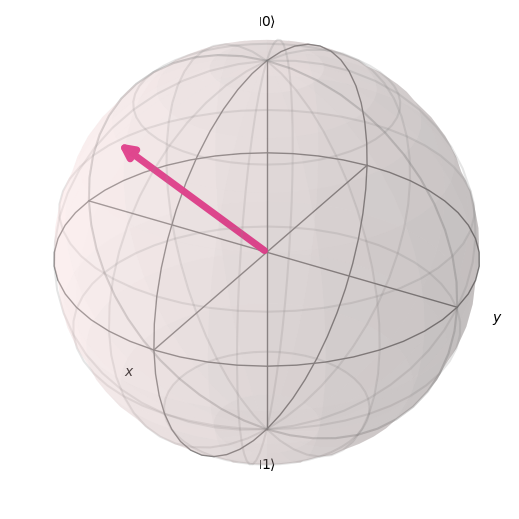

In [2]:
from qiskit.visualization import plot_bloch_vector

r = [rx, ry, rz]
plot_bloch_vector(r)

## 3. Quantum state tomography 

Although measuring the quantum state in the computational basis ($|0\rangle$ and $|1\rangle$) will eliminate the phase information (complex number information), we can still estimate the value of $r_x, r_y, r_z$ by performing **quantum state tomography** for density matrix $\rho$. 

This approach requires many copies of $|\psi\rangle$, which could be obtained by repeating the preparation process (not clonning states, but repeating preparation processes).

Given the form:
$$\rho = \frac{1}{2}(I + r_x X + r_y Y + r_z Z$$
it holds that 
$$Tr(X\rho) = r_x,\ Tr(Y\rho) = r_y,\ Tr(Z\rho) = r_z$$

In each case,
$$Tr(X\rho) = \langle0|X\rho|0\rangle + \langle1|X\rho|1\rangle = \alpha\beta^* + \beta\alpha^*$$
$$Tr(Y\rho) = \langle0|Y\rho|0\rangle + \langle1|Y\rho|1\rangle = i(\alpha\beta^* - \alpha^*\beta)$$
$$Tr(Z\rho) = \langle0|Z\rho|0\rangle + \langle1|Z\rho|1\rangle = |\alpha|^2 - |\beta|^2$$

note that 
$$\rho = |\psi\rangle\langle\psi|,\ |\psi\rangle = \alpha|0\rangle + \beta|1\rangle$$
$$X = |1\rangle\langle0| + |0\rangle\langle1|,\ Y = i|1\rangle\langle 0| - i|0\rangle\langle 1|,\ Z = |0\rangle\langle0| - |1\rangle\langle1|$$

#### Estimate $r_z$ value
The $r_z$ can be obtained by probability of $|0\rangle$ - probability of $|1\rangle$. So we can get the staticstics of the measurement to estimate the probabilities above by creating a quantum state with repeated preparation.

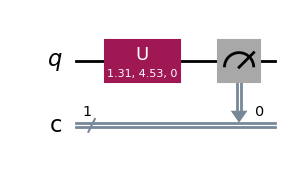

In [3]:
from qiskit import QuantumCircuit

# create a 1-qubit quantum state psi from theta, varphi parameters
qc = QuantumCircuit(1, 1)
qc.u(theta, varphi, 0.0, 0) #thea and varphi are generated with random number

# measure in computational basis
qc.measure(0, 0)

qc.draw(output="mpl")

{'0': 9364, '1': 5636}


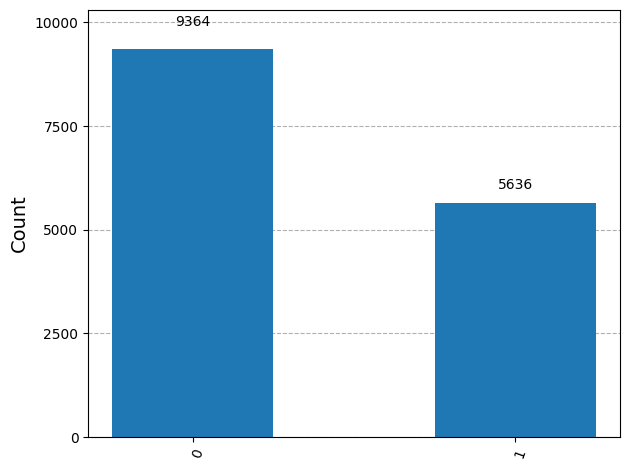

In [4]:
#Sampler simulator
from qiskit.primitives import StatevectorSampler
sampler_sim = StatevectorSampler()

nshots = 15000
# Execute it
job = sampler_sim.run([qc], shots = nshots) # defoult shot number is 1024

# Result
results = job.result()
counts = results[0].data.c.get_counts()
print(counts)

# Plot the result histogram
from qiskit.visualization import plot_histogram
plot_histogram(counts)

In [5]:
rz_approx = (counts["0"] - counts["1"]) / nshots

print("rz = ", rz, " and approx of rz = ", rz_approx)

rz =  0.2577405946274022  and approx of rz =  0.24853333333333333


#### Estimate $r_x$ value

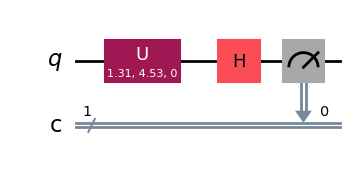

In [6]:
# create a 1-qubit quantum state psi from theta, varphi parameters
qc = QuantumCircuit(1, 1)
qc.u(theta, varphi, 0.0, 0)

qc.h(0)
qc.measure(0, 0)

qc.draw(output="mpl")

{'1': 8877, '0': 6123}


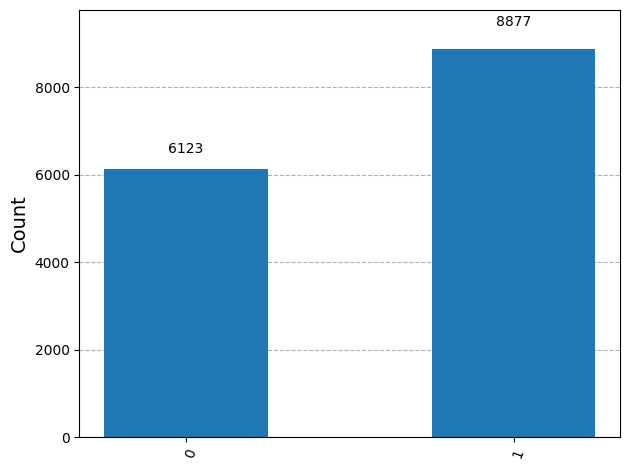

In [7]:
#Sampler simulator
from qiskit.primitives import StatevectorSampler
sampler_sim = StatevectorSampler()

nshots = 15000
# Execute it
job = sampler_sim.run([qc], shots = nshots) # defoult shot number is 1024

# Result
results = job.result()
counts = results[0].data.c.get_counts()
print(counts)

# Plot the result histogram
from qiskit.visualization import plot_histogram
plot_histogram(counts)

In [8]:
rx_approx = (counts["0"] - counts["1"]) / nshots

print("rz = ", rz, " and approx of rz = ", rz_approx)

rz =  0.2577405946274022  and approx of rz =  0.24853333333333333


#### Estimate $r_y$ value

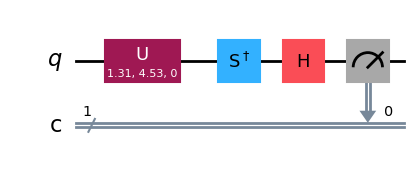

In [9]:
# create a 1-qubit quantum state psi from theta, varphi parameters
qc = QuantumCircuit(1, 1)
qc.u(theta, varphi, 0.0, 0)

qc.sdg(0)
qc.h(0)
qc.measure(0, 0)

qc.draw(output="mpl")

{'1': 14628, '0': 372}


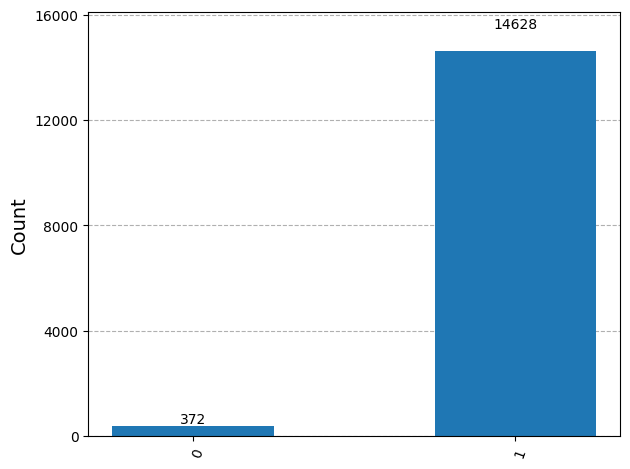

In [10]:
#Sampler simulator
from qiskit.primitives import StatevectorSampler
sampler_sim = StatevectorSampler()

nshots = 15000
# Execute it
job = sampler_sim.run([qc], shots = nshots) # defoult shot number is 1024

# Result
results = job.result()
counts = results[0].data.c.get_counts()
print(counts)

# Plot the result histogram
from qiskit.visualization import plot_histogram
plot_histogram(counts)

In [11]:
ry_approx = (counts["0"] - counts["1"]) / nshots

print("rz = ", rz, " and approx of rz = ", rz_approx)

rz =  0.2577405946274022  and approx of rz =  0.24853333333333333


#### Write out the full vector after estimated all components of $\vec{r}$

In [12]:
print("Estimated vector is (", rx_approx, ",", ry_approx, ",", rz_approx, ").")
print("Original random vector was (" + str(rx) + ", " + str(ry) + ", " + str(rz) + ").")

Estimated vector is ( -0.1836 , -0.9504 , 0.24853333333333333 ).
Original random vector was (-0.1791150283307452, -0.9494670044331133, 0.2577405946274022).


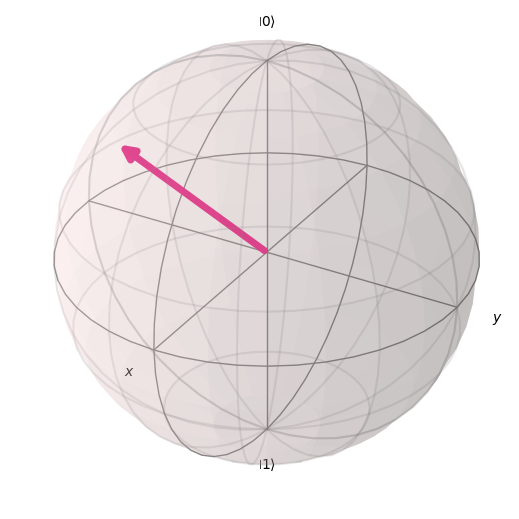

In [13]:
#from qiskit.visualization import plot_bloch_vector

r = [rx_approx, ry_approx, rz_approx]
plot_bloch_vector(r)

#### The core idea of single-qubit quantum state tomography
Due to the fact that quantum hardware natively measures in the computational (Z) basis. To obtain ⟨X⟩ or ⟨Y⟩, we first apply a basis rotation so that the X- or Y-eigenstates become Z-eigenstates, then perform the usual Z measurement.

Physically, you are rotating the quantum state before measurement.
Mathematically, these two descriptions are equivalent:
$$\langle\psi|X|\psi\rangle = \langle\psi|H^\dagger ZH|\psi \rangle = \langle H\psi |Z|H\psi\rangle$$

## 4. Quantum teleportation

Alice teleport the unknown quantum state to Bob by performing a series of quantum oeprations and sending him two bits of classical information.

### 4.1 Quantum circuit simulating the quantm teleportation
These will be implemented in detail below:

1. Alice entangles $|\psi\rangle$ with her part of the e-bit using the CNOT gate.
2. Alice appliees a Hadamard gate to $|\psi\rangle$, and measures both her qubits in the computational basis.
3. Alice sends Bob her measurement results (either "00", "01", "10", or "11")
4. Bob performs a correction operator based on Alice's two-bit of information on his part of the e-bit pair
   - If "00", Bob does nothing
   - If "01", Bob applies Z gate
   - If "10", Bob applies X gate
   - If "11", Bob applies iY = ZX gate
5. Bob's part of the e-bit becomes $|\psi\rangle$


### 4.2 Quantum circuit simulating the quantum teleportation

As always, we will apply the Qiskit patterns framework:\
**Step 1: Map problem to quantum circuits and operators.**\
Step 2: Optimize for target hardware.\
Step 3: Execute the circuit.\
Step 4: Post-process the results.

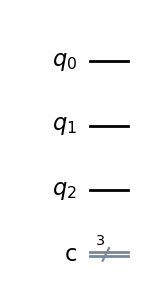

In [14]:
from qiskit import QuantumCircuit
import numpy as np
# create 3-qubits circuit
qc = QuantumCircuit(3, 3)

qc.draw(output="mpl")

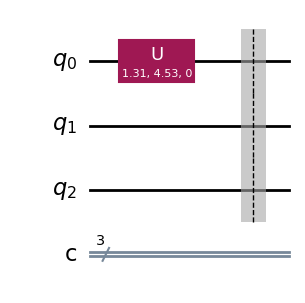

In [15]:
import numpy as np

# create a random 1-qubit state from a random (theta, varphi) to define r vector
#np.random.seed(1)  # fixing seed for repeatibility

#theta = np.random.uniform(0.0, 1.0) * np.pi  # from 0 to pi
#varphi = np.random.uniform(0.0, 2.0) * np.pi  # from 0 to 2*pi

# Create the unknown quantum state using the u-gate. Alice has this.
qc.u(theta, varphi, 0.0, 0) #theta and varphi are defined previously with random generator
qc.barrier()  # for visual separation

qc.draw(output="mpl")

we can visualize the state we've created, but only because we know what parameters were used in the **U** gate. If this state had emerged from a complicated quantum process, the state would not be knowable without running the process to create the state many times, and collecting statistics as in tomography.

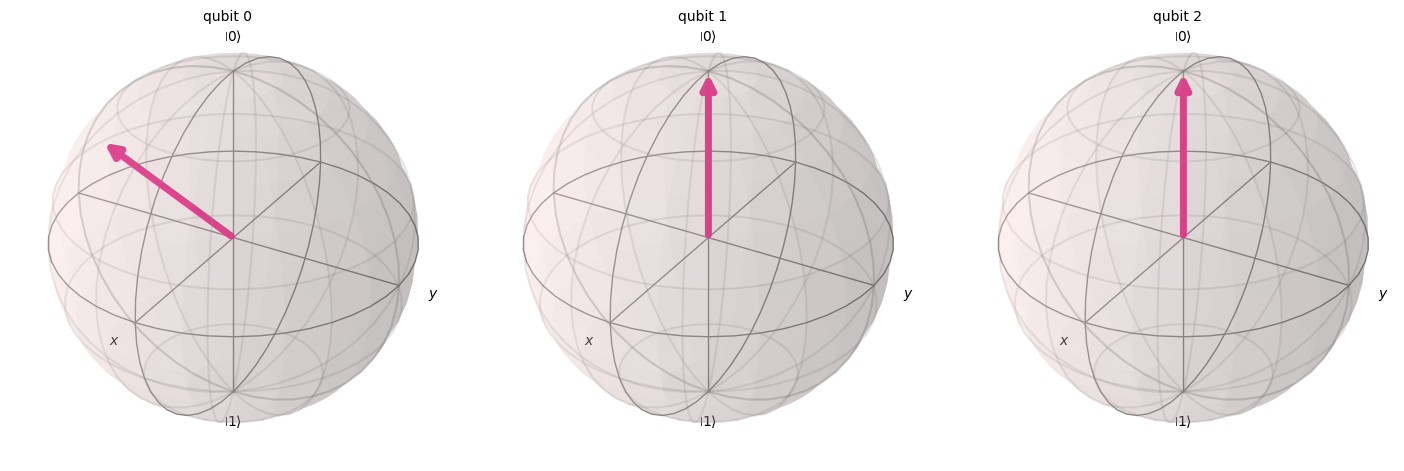

In [16]:
# show the quantum state on bloch sphere
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

out_vector = Statevector(qc)


plot_bloch_multivector(out_vector)

We create the shared entangle pair between Alice and Bob. Even though they might have set up the shared state *before* the unknow state $|\psi\rangle$ was ever created, we can still switch the order here for visualization convenience due to the fact that those things happens on different qubits.

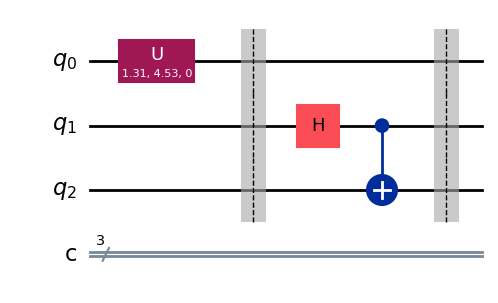

In [17]:
# Alice and Bob are together in the same place and set up an entangled pair.
qc.h(1)
qc.cx(1, 2)
qc.barrier()  # for visual separation.
# We can consider that Alice and Bob might move their qubits to different physical locations, now.

qc.draw(output="mpl")

Next, Alice entangles $|\psi\rangle$ with her part of the shared e-bit, using the **CX** gate and **H** gate, and measures them in the computational basis.

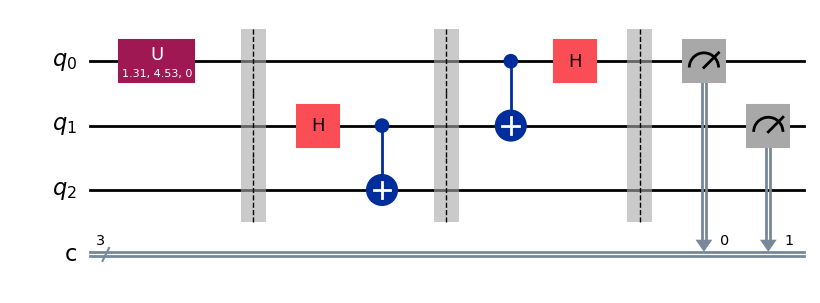

In [18]:
# Alice entangles the unknown state with her part of the e-bit, using the CNOT gate and H gate.
qc.cx(0, 1)
qc.h(0)
qc.barrier()

# Alice measures the two qubits.
qc.measure(0, 0)
qc.measure(1, 1)

qc.draw(output="mpl")

Alice sends Bob her measurement results (information about the classical bit, either "00", "01", "10", or "11"), and Bob performs a correction operator on his part of the shared e-bit based on Alice's two bits of information . Then, Bob's qubits becomes $|\psi\rangle$.

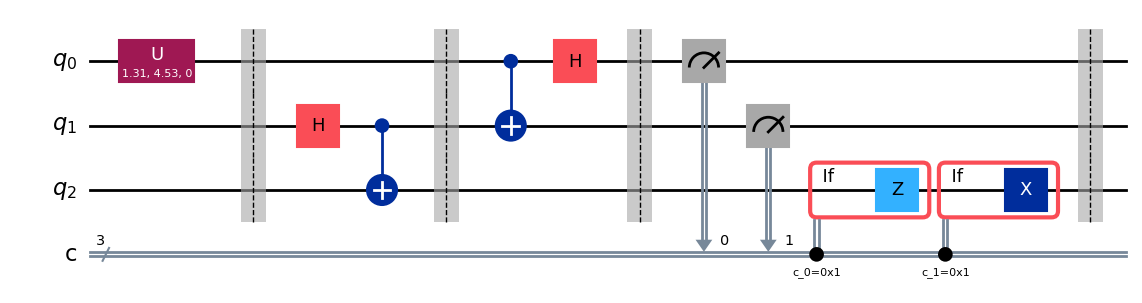

In [19]:
# Alice sent the results to Bob. Bob applies correction
with qc.if_test((0, 1)): #execute the operations inside only if classical bit 0 equals 1
    qc.z(2)
with qc.if_test((1, 1)): #execute the operations inside only if classical bit 1 equals 1
    qc.x(2)
qc.barrier()

qc.draw(output="mpl")

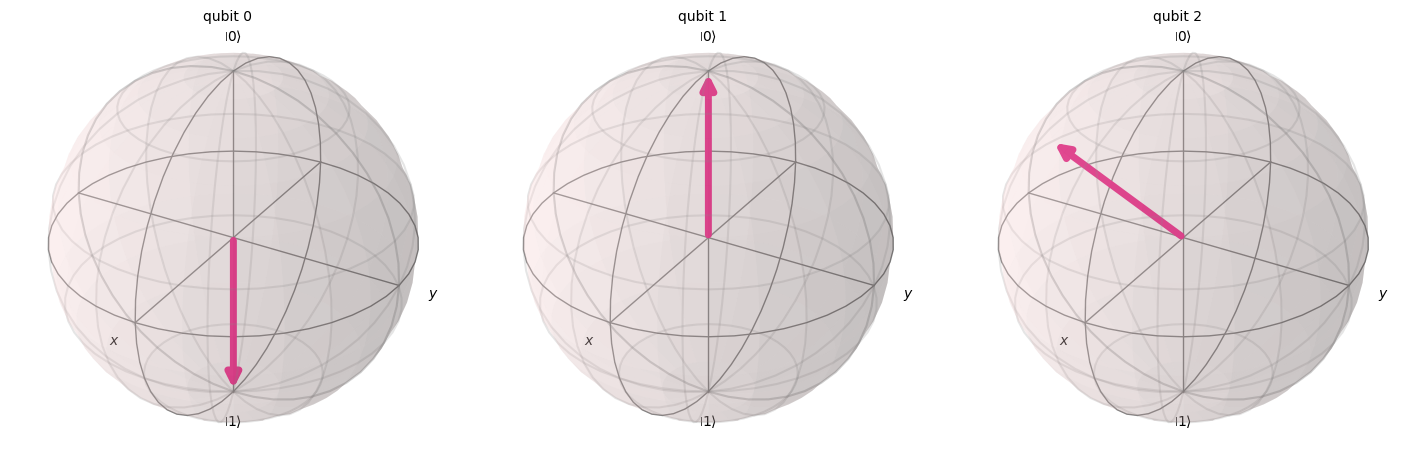

In [101]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_bloch_multivector

#qc.save_statevector() #uncomment this line for the firt execution.

backend = AerSimulator(method="statevector")
result = backend.run(qc, shots=1).result()

out_vector = result.get_statevector()
plot_bloch_multivector(out_vector)

You can run above cell a few times to make sure. You might notice that the qubits 0 and 1 change states, but qubit 2 is always in the state $|\psi\rangle$

### 4.3 Confirm the result by applying U inverse

If Bob's qubit is indeed the $|\psi\rangle$ then we can perform the inverse of the U gate to get an outcome "0".\
Note: Since **U** is an unitary matrix ($U^{-1} U$ = $I$), and $U|0\rangle =|\psi\rangle$ then 
$$U^{-1} |\psi\rangle = U^{-1} U|0\rangle = |0\rangle$$

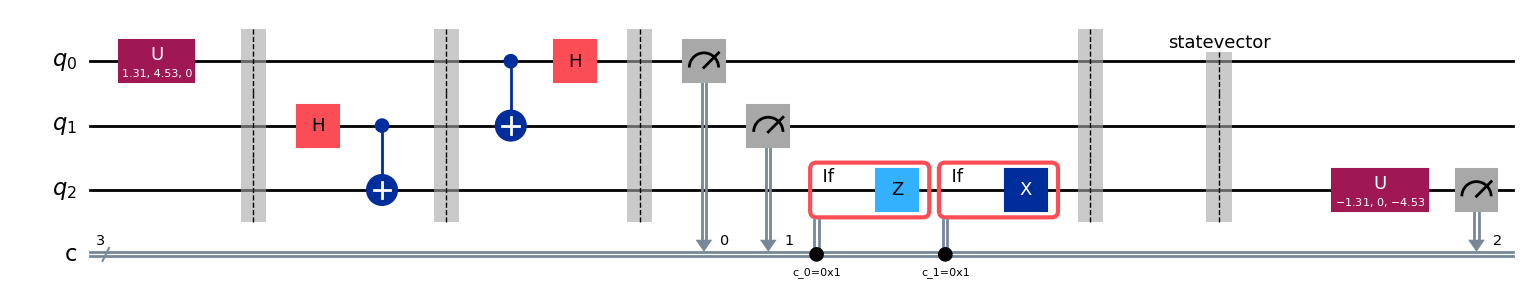

In [102]:
# Apply the inverse of u-gate to measure |0>
qc.u(theta, varphi, 0.0, 2).inverse()  # inverse of u(theta,varphi,0.0)
qc.measure(2, 2)  # add measurement gate

qc.draw(output="mpl")

{'001': 3810, '010': 3808, '011': 3732, '000': 3650}


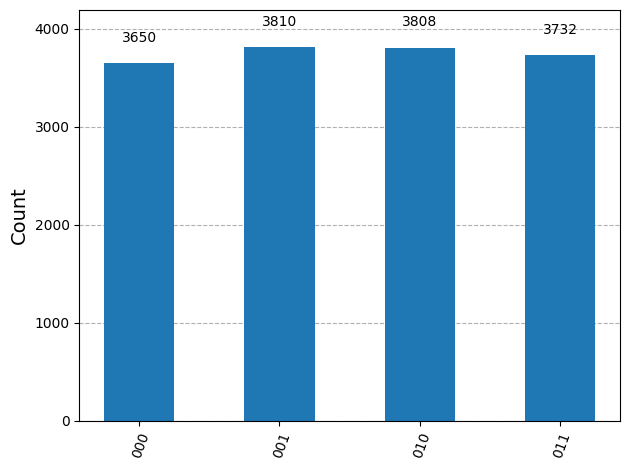

In [103]:
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import Sampler
from qiskit.visualization import plot_histogram

# Define backend
backend = AerSimulator()

# Transpile to backend
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_qc = pm.run(qc)

# Run the job
sampler = Sampler(mode=backend)
job = sampler.run([isa_qc], shots=nshots)
result = job.result()

# Extract counts data
counts = result[0].data.c.get_counts()
print(counts)

# Plot the counts in a histogram
plot_histogram(counts)

This shows we have a 100% chance of measuring $q_2$ in the state $|0\rangle$ (qubit 2 is the left-most qubit in little endian notation).

### 4.4 Teleportation on a real quantum computer

**Step 1: Map problem to quantum circuits and operators.**\
Step 2: Optimize for target hardware.\
Step 3: Execute the circuit.\
Step 4: Post-process the results.

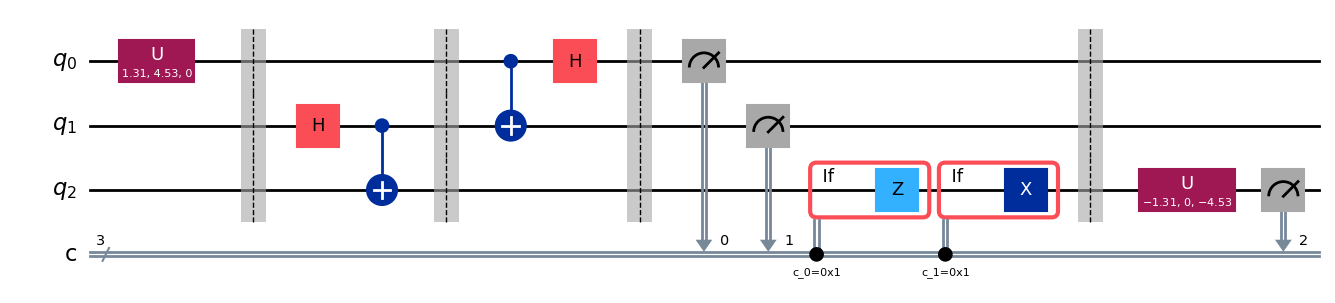

In [105]:
#Create the circuit with 3-qubits and 3 bit

qc = QuantumCircuit(3, 3)

# Alice creates an unkown quantum state using the u-gate.
qc.u(theta, varphi, 0.0, 0)
qc.barrier() # for visual separation

# Eve creates EPR pair and sends q1 to Alice and q2 to Bob
qc.h(1)
qc.cx(1, 2)
qc.barrier()

# Alice entangles the unknown state with her EPR part, using the CNOT gate and H gate.
qc.cx(0, 1)
qc.h(0)
qc.barrier()

# Alice measures the two qubits.
qc.measure(0, 0)
qc.measure(1, 1)

# Alice sent the results to Bob. Now, Bob applies correction
with qc.if_test((0, 1)):
    qc.z(2)
with qc.if_test((1, 1)):
    qc.x(2)
qc.barrier()

# Apply the inverse of u-gate to measure |0>
# this is only for verification purpose after the quantum state has been teleported.
qc.u(theta, varphi, 0.0, 2).inverse()
qc.measure(2, 2)

qc.draw("mpl")


Step 1: Map problem to quantum circuits and operators.\
**Step 2: Optimize for target hardware.**\
Step 3: Execute the circuit.\
Step 4: Post-process the results.

In [107]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
service.backends()


[<IBMBackend('ibm_berlin')>, <IBMBackend('ibm_aachen')>]

In [115]:
# You can also identify the least busy device
#backend = service.least_busy(operational=True)
#print("The least busy device is ", backend)
backend = service.backend('ibm_aachen')
print("The selected device is ", backend)

The selected device is  <IBMBackend('ibm_aachen')>


Check the coupling map of the selected device.

In [110]:
print(backend.coupling_map)

[[0, 1], [0, 10], [1, 0], [1, 2], [1, 11], [2, 1], [2, 3], [2, 12], [3, 2], [3, 4], [3, 13], [4, 3], [4, 5], [4, 14], [5, 4], [5, 6], [5, 15], [6, 5], [6, 7], [6, 16], [7, 6], [7, 8], [7, 17], [8, 7], [8, 9], [8, 18], [9, 8], [9, 19], [10, 0], [10, 11], [10, 20], [11, 1], [11, 10], [11, 12], [11, 21], [12, 2], [12, 11], [12, 13], [12, 22], [13, 3], [13, 12], [13, 14], [13, 23], [14, 4], [14, 13], [14, 15], [14, 24], [15, 5], [15, 14], [15, 16], [15, 25], [16, 6], [16, 15], [16, 17], [16, 26], [17, 7], [17, 16], [17, 18], [17, 27], [18, 8], [18, 17], [18, 19], [18, 28], [19, 9], [19, 18], [19, 29], [20, 10], [20, 21], [20, 30], [21, 11], [21, 20], [21, 22], [21, 31], [22, 12], [22, 21], [22, 23], [22, 32], [23, 13], [23, 22], [23, 24], [23, 33], [24, 14], [24, 23], [24, 25], [24, 34], [25, 15], [25, 24], [25, 26], [25, 35], [26, 16], [26, 25], [26, 27], [26, 36], [27, 17], [27, 26], [27, 28], [27, 37], [28, 18], [28, 27], [28, 29], [28, 38], [29, 19], [29, 28], [29, 39], [30, 20], [30, 

Different devices might have different coupling maps, native gates (gates the gardware can execute), and within each device there might has some qubits and couplers that are more performant than others.

Transpiling the circuit rewrites the abstract quantum circuit using gates the target quantum computer can execute, and selects the optimal mapping to physical qubits (among other things).

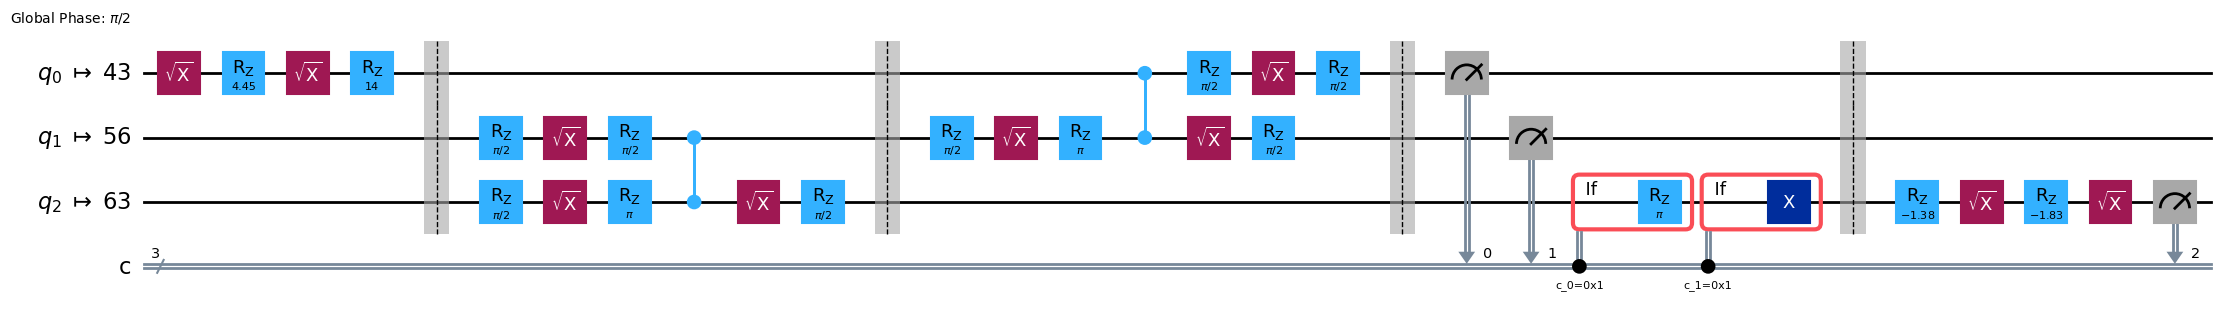

In [116]:
# Step 2: Optimize for target hardware
# Transpile the circuit into basis gates executable on the hardware
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(backend=backend, optimization_level=2)
qc_compiled = pm.run(qc)

qc_compiled.draw("mpl", idle_wires=False, fold=-1)

Step 1: Map problem to quantum circuits and operators.\
Step 2: Optimize for target hardware.\
**Step 3: Execute the circuit.**\
Step 4: Post-process the results.

In [117]:
# Step 3: Execute the target circuit
sampler = Sampler(backend)
job = sampler.run([qc_compiled])
job_id = job.job_id()
print("job id:", job_id)

job id: d8cmie01bidc739sj460


In [118]:
# Check the job status
job.status()

'DONE'

In [120]:
# Execute after 'DONE' is displayed
result_real = job.result()
print(result_real[0].data.c.get_counts())

{'011': 923, '111': 72, '010': 887, '001': 973, '000': 1043, '110': 70, '101': 72, '100': 56}


Step 1: Map problem to quantum circuits and operators.\
Step 2: Optimize for target hardware.\
Step 3: Execute the circuit.\
**Step 4: Post-process the results.**

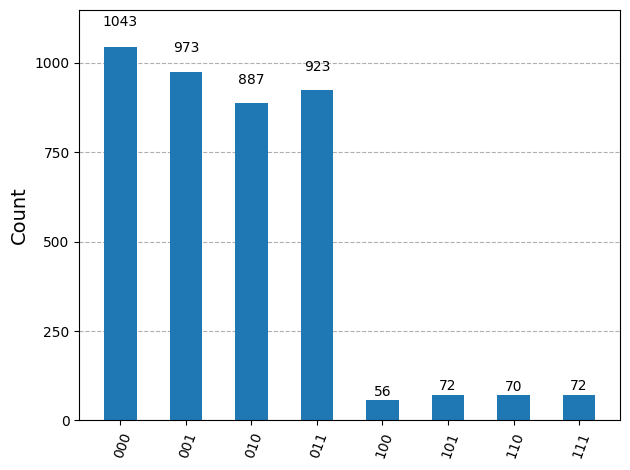

In [121]:
# Step 4: Post-process the results
from qiskit.visualization import plot_histogram

plot_histogram(result_real[0].data.c.get_counts())

You can interpret the results above directly. Or, using ***marginal_count***, you can trace out Bob's results on qubit 2.

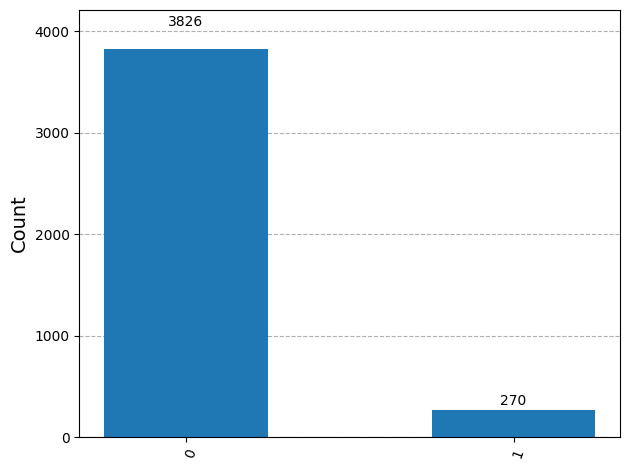

In [122]:
# trace out Bob's results on qubit 2
from qiskit.result import marginal_counts

bobs_qubit = 2
real_counts = result_real[0].data.c.get_counts()
bobs_counts = marginal_counts(real_counts, [bobs_qubit])
plot_histogram(bobs_counts)

There are a few results in which we measured $|1\rangle$. These are due to noise and errors.

In particular, dynamic circuits tend to have a higher error rate because of the time-consuming measurement in the middle of the circuit.
For example in the teleportation instance:
the work flow includes measure $q_0$, $q_1$ -> classical processing -> apply X/Z on $q_2$. This requires Bob's qubit $q_2$ to remain coherent during the entire measurement and classical feedback process, which increases the overall error rate.

### 4.5 Key takeaways on quantum teleportation

We can transport a quantum state to a distant friend by sharing a pair of entnagled qubits (an e-bit).

1. The quantum teleportation cannot send quantum state faster than light because Alice has to tell Bob the measurement results in a classical way.
2. Quantum teleportation does not break the "no cloning theorem" since Alice would lost the information of her qubits in the measurement. After the measurement, the original quantum state of Alice's qubits collapsed to a $|0\rangle$ or $|1\rangle$.

## 5. Superdense Coding
### 5.1 The protocol of superdense coding
In teleportation, classical communication was available to the friends, and the goal was to send a quantum state. Here, classical communication is not accessible and they use the transfer of **one qubit** to share **two bits of classical information**.

1. Alice perfroms one of the following operations on her part of e-bit.
   - if $c_1 c_2$ = 00, she does nothing
   - if $c_1 c_2$ = 10, she applies Z gate
   - if $c_1 c_2$ = 10, she applies X gate
   - if $c_1 c_2$ = 11, she applies Z gate and X gate.
3. Alice sends her part of the e-bit to Bob's location.
4. Bob applies a CNOT gate with the qubit from Alices as control and his qubit as target, then applies H gate to the qubit from Alice, and measures the two qubits.
5. The outcome of the measurement implies the operation done by Alice, which encodes the information of the **2** classical bits.

### 5.2 Quantum circuit simulating the superdense coding

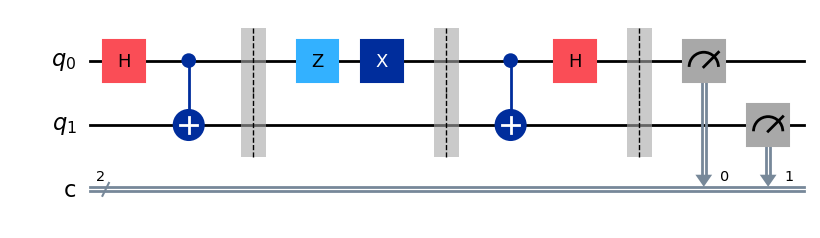

In [1]:
from qiskit import QuantumCircuit

# Step 1: Map problem to quantum circuits and operators
# Create 2-qubits circuit
qc = QuantumCircuit(2, 2)

# Eve creates EPR pair and send q0 to Alice and q1 to Bob
qc.h(0)
qc.cx(0, 1)
qc.barrier()

# set message which Alice wants to transform to Bob
msg = "11"  # You can change the message

if msg == "00":
    pass
elif msg == "10":
    qc.x(0)
elif msg == "01":
    qc.z(0)
elif msg == "11":
    qc.z(0)
    qc.x(0)

qc.barrier()
# Bob receives EPR qubit from Alice and performs unitary operations
qc.cx(0, 1)
qc.h(0)
qc.barrier()

# Bob measures q0 and q1
qc.measure(0, 0)
qc.measure(1, 1)

qc.draw(output="mpl")

In [2]:
# We will execute on a simulator first
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import Sampler

# Define backend
backend = AerSimulator()
shots = 1000

# Transpile to backend
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_qc = pm.run(qc)

# Run the job
sampler = Sampler(mode=backend)
job_sim = sampler.run([isa_qc], shots=shots)
result_sim = job_sim.result()

# Extract counts data
counts = result_sim[0].data.c.get_counts()
print(counts)

{'11': 1000}


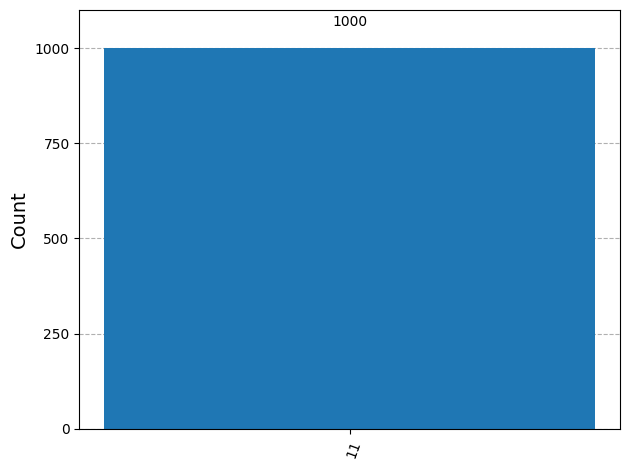

In [3]:
# Visualize the results
from qiskit.visualization import plot_histogram

plot_histogram(counts)

Try it with a real quantum computer.

In [4]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = service.least_busy(operational=True)
print("The least busy device is ", backend)

The least busy device is  <IBMBackend('ibm_berlin')>


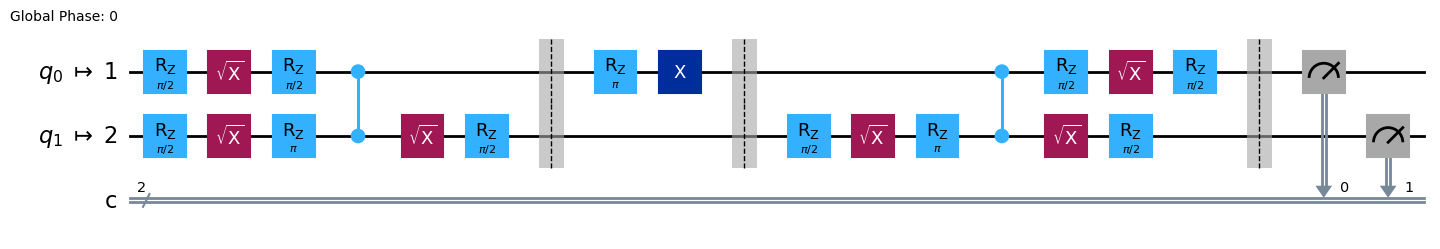

In [5]:
# Step 1 was already completed before the simulator job above.
# Step 2: Optimize for target hardware
# Transpile the circuit into basis gates executable on the hardware
pm = generate_preset_pass_manager(backend=backend, optimization_level=2)
qc_compiled = pm.run(qc)

qc_compiled.draw("mpl", idle_wires=False)

In [6]:
# Step 3:Execute the target circuit
sampler = Sampler(backend)
job = sampler.run([qc_compiled])
job_id = job.job_id()
print("job id:", job_id)

job id: d8elv6odrk3c73fticeg


In [9]:
# Check the job status
job.status()

'DONE'

In [8]:
# If the Notebook session got disconnected you can also check your job status by running the following code
# from qiskit_ibm_runtime import QiskitRuntimeService
# service = QiskitRuntimeService()
job = service.job(job_id)  # Input your job-id between the quotations
job.status()

'RUNNING'

In [10]:
# Execute after job has successfully run
real_result = job.result()
print(real_result[0].data.c.get_counts())

{'11': 3936, '01': 80, '00': 8, '10': 72}


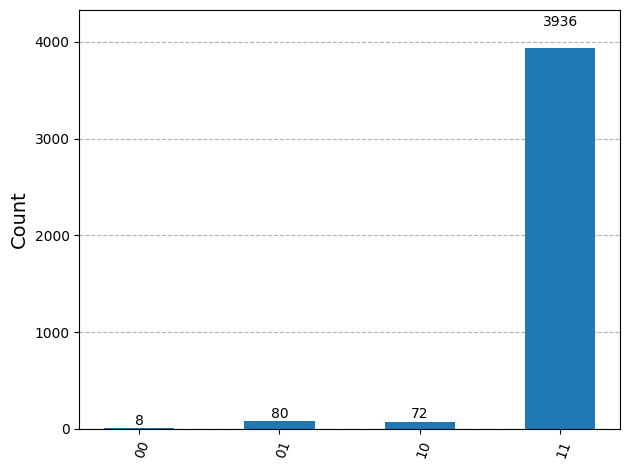

In [11]:
# Step 4: post-process the results
from qiskit.visualization import plot_histogram

plot_histogram(real_result[0].data.c.get_counts())

Note that superdense coding on a real quantum computer showed fewer errors. The reason might be that quantum teleportation uses dynamic circuits, and superdense coding does not.

## 6. Summary

- Quantum teleportation: Although we cannot copy quantum states, we can teleport unknown quantum states by having shared entanglement.
- Quantum superdense coding: A shared entangled pair, and transfer of one qubit, enable the communication of two bits of classical information.